<a href="https://colab.research.google.com/github/covillarreal/Aprendizaje-Automatico-2/blob/main/TP4_VILLARREAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 — Aprendizaje por Refuerzo

## CONSTANZA VILLARREAL - 43230810
## Tutorial elegido: Agente A2C en LunarLander

En este trabajo práctico se reproduce y adapta el tutorial oficial de Gymnasium sobre el entrenamiento de un agente A2C utilizando entornos vectorizados.

El entorno elegido es LunarLander, donde el objetivo del agente es aprender a controlar una nave para aterrizar correctamente en una zona determinada.

Este trabajo permite observar cómo un agente aprende mediante interacción con el entorno, recibiendo recompensas o penalizaciones según sus acciones.

A lo largo del notebook se traducen y comentan las secciones principales del tutorial, agregando explicaciones propias para comprender mejor:
- el entorno LunarLander;
- el algoritmo A2C;
- la función del actor y del critic;
- el entrenamiento del agente;
- la evolución de la recompensa.

## Instalación de librerías

Para ejecutar este tutorial en Google Colab es necesario instalar algunas librerías adicionales utilizadas por Gymnasium y el entorno LunarLander.

En particular:

- gymnasium: permite crear y administrar entornos de aprendizaje por refuerzo.
- box2d-py: proporciona la simulación física utilizada por LunarLander.
- swig: dependencia requerida para compilar algunos componentes de Box2D.

Estas instalaciones solo deben realizarse una vez al iniciar el notebook.

In [ ]:
# Instalación de librerías necesarias para el entorno LunarLander

!pip install gymnasium[box2d]
!pip install swig

## Importación de librerías

En esta sección se importan las librerías necesarias para implementar el agente A2C.

Se utilizan herramientas para crear el entorno de aprendizaje por refuerzo, construir redes neuronales con PyTorch, realizar operaciones numéricas y visualizar los resultados del entrenamiento.

In [ ]:
# Permite usar anotaciones de tipos más modernas en Python
from __future__ import annotations

# Librería para manejar archivos y carpetas del sistema
import os

# Librería para realizar gráficos
import matplotlib.pyplot as plt

# Librería para operaciones numéricas
import numpy as np

# Librerías principales de PyTorch
import torch
import torch.nn as nn
from torch import optim

# Barra de progreso para visualizar el avance del entrenamiento
from tqdm import tqdm

# Librería Gymnasium para crear entornos de aprendizaje por refuerzo
import gymnasium as gym

## Algoritmo A2C (Advantage Actor-Critic)

El algoritmo A2C combina dos redes neuronales que trabajan juntas:

- Actor: decide qué acción realizar.
- Critic: evalúa qué tan buena es la situación actual.

Mientras el actor aprende qué hacer, el critic ayuda a corregir sus decisiones estimando el valor esperado de cada estado.

Una ventaja importante de este enfoque es que suele aprender más rápido y de forma más estable que otros métodos de aprendizaje por refuerzo más simples.

En este trabajo también se utilizan entornos vectorizados, lo que permite ejecutar varias simulaciones de LunarLander al mismo tiempo para acelerar el entrenamiento.

## Definición del agente

A continuación se implementa la clase principal del agente A2C.

Esta clase contiene:

- la red Actor;
- la red Critic;
- las funciones para seleccionar acciones;
- el cálculo de pérdidas;
- la actualización de los parámetros de las redes.

La implementación está basada en el tutorial oficial de Gymnasium, con comentarios traducidos al español para facilitar su comprensión.

In [ ]:
class A2C(nn.Module):
    """
    Esta es la clase del agente Advantage Actor-Critic (A2C) que uso. Funciona de forma síncrona.

    Argumentos:
        n_features: La cantidad de características que tiene el estado de entrada. Es como cuánta información recibo del entorno.
        n_actions: La cantidad de acciones que mi agente puede tomar. Por ejemplo, en LunarLander, cuántos movimientos puede hacer.
        device: El dispositivo donde voy a hacer los cálculos (CPU o GPU). Si tengo una GPU, a veces es más rápido, pero para este código, la CPU está bien.
        critic_lr: La tasa de aprendizaje para mi red 'Critic'. Generalmente es un poco más alta que la del actor.
        actor_lr: La tasa de aprendizaje para mi red 'Actor'.
        n_envs: La cantidad de entornos que ejecuto al mismo tiempo (en paralelo) para recolectar experiencias. Esto me ayuda a aprender más rápido.
    """

    def __init__(
        self,
        n_features: int,
        n_actions: int,
        device: torch.device,
        critic_lr: float,
        actor_lr: float,
        n_envs: int,
    ) -> None:
        """Aquí inicializo mis redes Actor y Critic, y también sus optimizadores."""
        super().__init__()
        self.device = device
        self.n_envs = n_envs

        critic_layers = [
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),  # Esta capa estima el valor del estado (V(s))
        ]

        actor_layers = [
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(
                32, n_actions
            ),  # Esta capa estima las probabilidades de las acciones (logits), que luego pasarán por una función softmax.
        ]

        # Aquí defino mis redes Actor y Critic
        self.critic = nn.Sequential(*critic_layers).to(self.device)
        self.actor = nn.Sequential(*actor_layers).to(self.device)

        # Y aquí defino los optimizadores para cada una de mis redes
        self.critic_optim = optim.RMSprop(self.critic.parameters(), lr=critic_lr)
        self.actor_optim = optim.RMSprop(self.actor.parameters(), lr=actor_lr)

    def forward(self, x: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Esta función realiza el paso 'hacia adelante' en mis redes.

        Argumentos:
            x: Un vector de estados que proceso en lotes (varios a la vez).

        Devuelve:
            state_values: Un tensor con los valores estimados de cada estado, con forma [n_envs,].
            action_logits_vec: Un tensor con las probabilidades (logits) de las acciones, con forma [n_envs, n_actions].
        """
        x = torch.Tensor(x).to(self.device)
        state_values = self.critic(x)  # La forma de esto es [n_envs,]
        action_logits_vec = self.actor(x)  # La forma de esto es [n_envs, n_actions]
        return (state_values, action_logits_vec)

    def select_action(
        self, x: np.ndarray
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Esta función me devuelve las acciones que elijo y la probabilidad logarítmica de esas acciones.

        Argumentos:
            x: Un vector de estados que proceso en lotes.

        Devuelve:
            actions: Un tensor con las acciones elegidas para cada entorno, con forma [n_envs].
            action_log_probs: Un tensor con la probabilidad logarítmica de cada acción elegida, con forma [n_envs].
            state_values: Un tensor con los valores estimados de los estados, con forma [n_envs].
            entropy: Un tensor que ayuda a medir la exploración de la política.
        """
        state_values, action_logits = self.forward(x)
        action_pd = torch.distributions.Categorical(
            logits=action_logits
        )  # Esto usa implícitamente la función softmax
        actions = action_pd.sample()
        action_log_probs = action_pd.log_prob(actions)
        entropy = action_pd.entropy()
        return actions, action_log_probs, state_values, entropy

    def get_losses(
        self,
        rewards: torch.Tensor,
        action_log_probs: torch.Tensor,
        value_preds: torch.Tensor,
        entropy: torch.Tensor,
        masks: torch.Tensor,
        gamma: float,
        lam: float,
        ent_coef: float,
        device: torch.device,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Esta función calcula la 'pérdida' de un pequeño grupo de transiciones (minibatch) que recolecté en una fase de muestreo.
        Uso la Estimación Generalizada de Ventaja (GAE) para calcular las ventajas (puedes ver más aquí: https://arxiv.org/abs/1506.02438).

        Argumentos:
            rewards: Un tensor con las recompensas de cada paso de tiempo en el episodio, con forma [n_steps_per_update, n_envs].
            action_log_probs: Un tensor con las probabilidades logarítmicas de las acciones que tomé en cada paso de tiempo, con forma [n_steps_per_update, n_envs].
            value_preds: Un tensor con las predicciones del valor del estado para cada paso de tiempo, con forma [n_steps_per_update, n_envs].
            masks: Un tensor que me dice si el episodio terminó en cada paso de tiempo, con forma [n_steps_per_update, n_envs].
            gamma: Es mi factor de descuento para las recompensas futuras.
            lam: Es un hiperparámetro para GAE. (Si `lam=1`, es como muestreo Monte-Carlo, con mucha variación pero sin sesgo. Si `lam=0`, es aprendizaje TD normal, con poca variación pero algo de sesgo porque las estimaciones las hace una red neuronal).
            device: El dispositivo donde realizo los cálculos (CPU o GPU).

        Devuelve:
            critic_loss: La pérdida de mi red Critic para este minibatch.
            actor_loss: La pérdida de mi red Actor para este minibatch.
        """
        T = len(rewards)
        advantages = torch.zeros(T, self.n_envs, device=device)

        # Calculo las ventajas usando GAE
        gae = 0.0
        for t in reversed(range(T - 1)):
            td_error = (
                rewards[t] + gamma * masks[t] * value_preds[t + 1] - value_preds[t]
            )
            gae = td_error + gamma * lam * masks[t] * gae
            advantages[t] = gae

        # Calculo la pérdida para mi Actor y Critic en este minibatch
        critic_loss = advantages.pow(2).mean()

        # Doy un 'bono' por tener más entropía (para fomentar que mi agente explore más)
        actor_loss = (
            -(advantages.detach() * action_log_probs).mean() - ent_coef * entropy.mean()
        )
        return (critic_loss, actor_loss)

    def update_parameters(
        self, critic_loss: torch.Tensor, actor_loss: torch.Tensor
    ) -> None:
        """
        Esta función actualiza los parámetros de mis redes Actor y Critic.

        Argumentos:
            critic_loss: La pérdida de mi red Critic.
            actor_loss: La pérdida de mi red Actor.
        """
        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()

## Configuración del entorno y de los hiperparámetros

Después de definir el agente A2C, configuro el entorno de entrenamiento y los principales hiperparámetros.

En este caso trabajo con `LunarLander-v3`, un entorno donde el agente debe aprender a controlar una nave para aterrizar correctamente.

El tutorial original utiliza entornos vectorizados, es decir, varias copias del mismo entorno ejecutándose al mismo tiempo. Esto permite recolectar más experiencias en menos tiempo y acelerar el entrenamiento.

Para que el notebook sea más liviano en Google Colab, reduje algunos valores respecto del tutorial original, manteniendo la lógica principal del algoritmo.

In [ ]:
# Hiperparámetros del entorno

# Cantidad de entornos que se ejecutan en paralelo
# En el tutorial original se utilizan 10 entornos.
# En este trabajo uso 5 para reducir el tiempo de ejecución en Google Colab.
n_envs = 5

# Cantidad de actualizaciones del entrenamiento
# En el tutorial original se usan 1000.
# Se reduce a 300 para que el entrenamiento sea más accesible.
n_updates = 300

# Cantidad de pasos que se recolectan antes de actualizar el modelo
# En el tutorial original se usan 128.
n_steps_per_update = 64

# No se utiliza randomización del dominio para mantener el ejemplo más simple
randomize_domain = False


# Hiperparámetros del agente

# Factor de descuento: indica cuánto peso tienen las recompensas futuras
gamma = 0.999

# Parámetro utilizado por GAE para calcular ventajas
lam = 0.95

# Coeficiente de entropía: fomenta la exploración del agente
ent_coef = 0.01

# Learning rate del actor
actor_lr = 0.001

# Learning rate del critic
critic_lr = 0.005

## Creación del entorno y del agente

En esta sección se crea el entorno `LunarLander-v3`.

Como el tutorial utiliza entornos vectorizados, se ejecutan varias simulaciones al mismo tiempo. Esto permite que el agente recolecte más experiencias y entrene de manera más eficiente.

También se obtienen la cantidad de variables del estado y la cantidad de acciones posibles, datos necesarios para inicializar el agente A2C.

In [ ]:
# Configuración del entorno

if randomize_domain:
    # Esta opción permite crear varios entornos con pequeñas diferencias
    # en gravedad, viento o turbulencia.
    # En este trabajo no se utiliza para mantener el ejemplo más simple.
    envs = gym.vector.AsyncVectorEnv(
        [
            lambda: gym.make(
                "LunarLander-v3",
                gravity=np.clip(
                    np.random.normal(loc=-10.0, scale=1.0),
                    a_min=-11.99,
                    a_max=-0.01
                ),
                enable_wind=np.random.choice([True, False]),
                wind_power=np.clip(
                    np.random.normal(loc=15.0, scale=1.0),
                    a_min=0.01,
                    a_max=19.99
                ),
                turbulence_power=np.clip(
                    np.random.normal(loc=1.5, scale=0.5),
                    a_min=0.01,
                    a_max=1.99
                ),
                max_episode_steps=600,
            )
            for i in range(n_envs)
        ]
    )
else:
    # Creo varios entornos LunarLander-v3 iguales ejecutándose en paralelo
    envs = gym.make_vec(
        "LunarLander-v3",
        num_envs=n_envs,
        max_episode_steps=600
    )

# Cantidad de características del estado observado por el agente
obs_shape = envs.single_observation_space.shape[0]

# Cantidad de acciones posibles del agente
action_shape = envs.single_action_space.n

# Utilizar GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inicializo el agente A2C con los valores definidos anteriormente
agent = A2C(
    obs_shape,
    action_shape,
    device,
    critic_lr,
    actor_lr,
    n_envs
)

print("Cantidad de variables del estado:", obs_shape)
print("Cantidad de acciones posibles:", action_shape)
print("Dispositivo utilizado:", device)

Cantidad de variables del estado: 8
Cantidad de acciones posibles: 4
Dispositivo utilizado: cuda


Se utilizó una GPU Tesla T4 disponible en Google Colab. Sin embargo, debido al tamaño reducido de las redes neuronales utilizadas por A2C en LunarLander, la mejora de rendimiento respecto de CPU no resulta tan significativa como en problemas que utilizan imágenes o modelos más grandes.

## Entrenamiento del agente A2C

En esta sección se entrena el agente A2C.

Durante el entrenamiento, el agente interactúa con varios entornos LunarLander en paralelo. En cada paso observa el estado, selecciona una acción, recibe una recompensa y guarda esa experiencia.

Luego, con esas experiencias, calcula la pérdida del Actor y del Critic, y actualiza los parámetros de ambas redes neuronales.

También se guardan métricas como:
- recompensas obtenidas;
- pérdida del Actor;
- pérdida del Critic;
- entropía de la política.

Estas métricas permiten analizar si el agente mejora durante el entrenamiento.

In [ ]:
# Creo un wrapper para guardar estadísticas de los episodios,
# como recompensas obtenidas y duración de cada episodio
envs_wrapper = gym.wrappers.vector.RecordEpisodeStatistics(
    envs,
    buffer_length=n_envs * n_updates
)

# Listas para guardar métricas durante el entrenamiento
critic_losses = []
actor_losses = []
entropies = []

# Bucle principal de entrenamiento
for sample_phase in tqdm(range(n_updates)):

    # En cada fase de muestreo guardo las experiencias recolectadas
    ep_value_preds = torch.zeros(n_steps_per_update, n_envs, device=device)
    ep_rewards = torch.zeros(n_steps_per_update, n_envs, device=device)
    ep_action_log_probs = torch.zeros(n_steps_per_update, n_envs, device=device)
    ep_entropies = torch.zeros(n_steps_per_update, n_envs, device=device)
    masks = torch.zeros(n_steps_per_update, n_envs, device=device)

    # Al inicio del entrenamiento reinicio todos los entornos
    if sample_phase == 0:
        states, info = envs_wrapper.reset(seed=42)

    # Recorro varios pasos dentro de los entornos paralelos
    for step in range(n_steps_per_update):

        # El agente selecciona una acción para cada entorno
        actions, action_log_probs, state_value_preds, entropy = agent.select_action(states)

        # Ejecuto las acciones en los entornos
        states, rewards, terminated, truncated, infos = envs_wrapper.step(
            actions.cpu().numpy()
        )

        # Guardo la información obtenida
        ep_value_preds[step] = torch.squeeze(state_value_preds)
        ep_rewards[step] = torch.tensor(rewards, device=device)
        ep_action_log_probs[step] = action_log_probs
        ep_entropies[step] = entropy

        # La máscara indica si el episodio sigue activo o terminó
        masks[step] = torch.tensor(
            [not term for term in terminated],
            device=device
        )

    # Calculo las pérdidas del Actor y del Critic
    critic_loss, actor_loss = agent.get_losses(
        ep_rewards,
        ep_action_log_probs,
        ep_value_preds,
        ep_entropies,
        masks,
        gamma,
        lam,
        ent_coef,
        device,
    )

    # Actualizo los parámetros de ambas redes
    agent.update_parameters(critic_loss, actor_loss)

    # Guardo métricas para graficar después
    critic_losses.append(critic_loss.detach().cpu().numpy())
    actor_losses.append(actor_loss.detach().cpu().numpy())
    entropies.append(ep_entropies.detach().mean().cpu().numpy())

100%|██████████| 300/300 [01:12<00:00,  4.11it/s]


## Análisis de resultados

Una vez finalizado el entrenamiento, se visualizan algunas métricas para observar la evolución del aprendizaje.

En particular se analizan:

- la pérdida del Critic;
- la pérdida del Actor;
- la entropía de la política.

Estas métricas permiten verificar si el agente está aprendiendo de manera estable y si mantiene un equilibrio adecuado entre exploración y explotación.

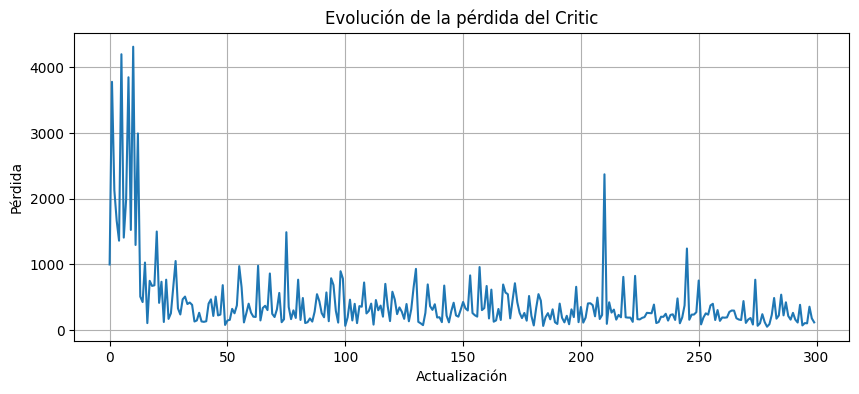

In [ ]:
# Graficar pérdida del Critic

plt.figure(figsize=(10, 4))
plt.plot(critic_losses)
plt.title("Evolución de la pérdida del Critic")
plt.xlabel("Actualización")
plt.ylabel("Pérdida")
plt.grid()
plt.show()

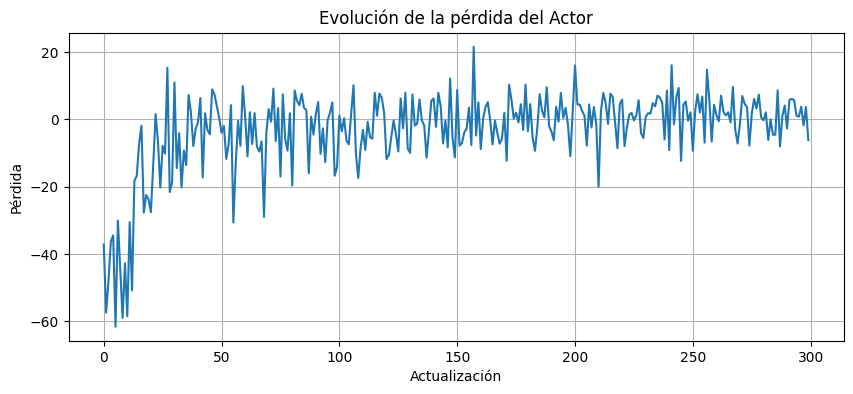

In [ ]:
# Graficar pérdida del Actor

plt.figure(figsize=(10, 4))
plt.plot(actor_losses)
plt.title("Evolución de la pérdida del Actor")
plt.xlabel("Actualización")
plt.ylabel("Pérdida")
plt.grid()
plt.show()

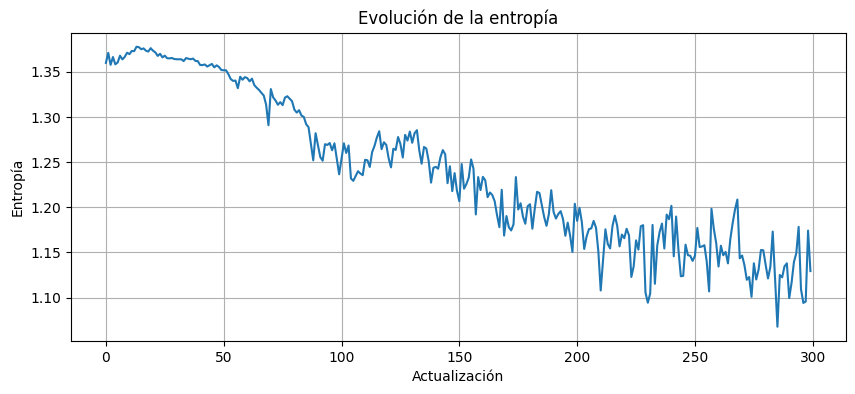

In [ ]:
# Graficar entropía

plt.figure(figsize=(10, 4))
plt.plot(entropies)
plt.title("Evolución de la entropía")
plt.xlabel("Actualización")
plt.ylabel("Entropía")
plt.grid()
plt.show()

### Interpretación de los resultados

Al analizar las métricas obtenidas durante el entrenamiento, se observa que el agente logró aprender progresivamente a interactuar con el entorno LunarLander.

En la pérdida del Critic se aprecia una disminución importante respecto de los valores iniciales. Aunque existen algunos picos durante el entrenamiento, esto es normal en aprendizaje por refuerzo debido a la naturaleza exploratoria del agente y a la variabilidad de las recompensas obtenidas.

En la pérdida del Actor puede observarse una gran variación durante las primeras actualizaciones. Con el avance del entrenamiento, los valores se estabilizan alrededor de cero, indicando que la política del agente comienza a consolidarse y requiere ajustes menos drásticos.

Por último, la entropía muestra una tendencia descendente a lo largo del entrenamiento. Esto indica que el agente reduce gradualmente la exploración aleatoria y comienza a tomar decisiones más consistentes basadas en la experiencia adquirida.

En conjunto, estas métricas sugieren que el entrenamiento fue estable y que el agente logró mejorar su comportamiento dentro del entorno.

### Análisis de la recompensa obtenida - Gráfica adicional de desempeño

El tutorial original no incluye una visualización específica de la evolución de las recompensas obtenidas por episodio. Debido a que la consigna solicita incorporar una métrica que permita observar el desempeño del agente, se agrega la siguiente gráfica utilizando las recompensas registradas durante el entrenamiento.

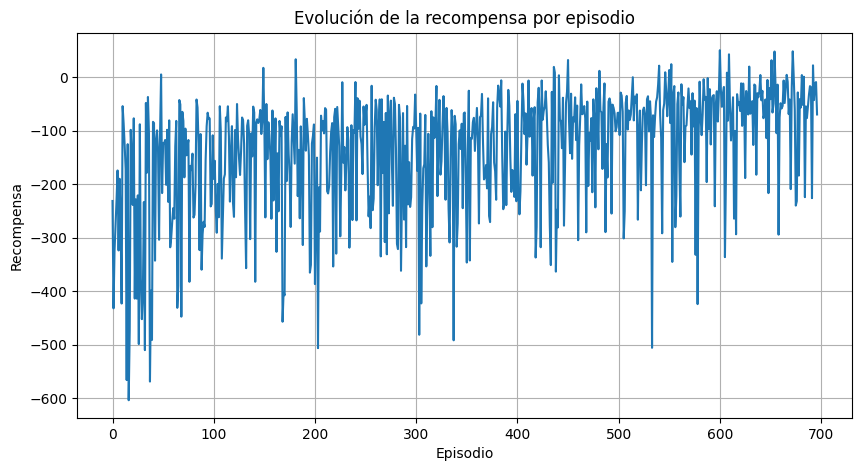

In [ ]:
# Recompensas obtenidas en cada episodio

episode_rewards = list(envs_wrapper.return_queue)

plt.figure(figsize=(10,5))
plt.plot(episode_rewards)

plt.title("Evolución de la recompensa por episodio")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.grid(True)

plt.show()

La gráfica de recompensas muestra una mejora gradual en el desempeño del agente a medida que avanza el entrenamiento.

Al comienzo predominan recompensas muy negativas, lo que indica que el agente todavía no comprende cómo controlar correctamente el módulo de aterrizaje y suele cometer errores frecuentes.

Con el paso de los episodios aparecen recompensas menos negativas e incluso algunos valores positivos. Esto sugiere que el agente comienza a aprender estrategias más adecuadas para mantenerse estable y acercarse a un aterrizaje exitoso.

Si bien el entrenamiento realizado no es suficiente para resolver completamente el entorno LunarLander-v3, los resultados muestran una tendencia positiva y evidencian que el algoritmo A2C logra mejorar progresivamente su comportamiento mediante la interacción con el entorno y las recompensas recibidas.

## Conclusiones

En este trabajo implementé y entrené un agente utilizando el algoritmo Advantage Actor-Critic (A2C) en el entorno LunarLander-v3 de Gymnasium.

A través del entrenamiento observé cómo el agente mejora progresivamente su desempeño a partir de las recompensas obtenidas durante la interacción con el entorno. Las métricas analizadas, como las pérdidas del Actor y del Critic, la entropía y la evolución de las recompensas, muestran que el agente logró aprender comportamientos más adecuados para controlar el módulo de aterrizaje.

Si bien el entrenamiento realizado no fue suficiente para resolver completamente el entorno, los resultados obtenidos evidencian una mejora respecto de los episodios iniciales, demostrando el funcionamiento del algoritmo A2C y su capacidad para aprender mediante prueba y error.

## Dificultades encontradas

La principal dificultad fue comprender la lógica general del algoritmo A2C y el papel que cumple cada una de sus redes neuronales.

También fue necesario familiarizarse con conceptos específicos del aprendizaje por refuerzo, como estados, acciones, recompensas, ventajas, entropía y entornos vectorizados.

Durante la implementación en Google Colab fue necesario instalar dependencias adicionales para ejecutar correctamente el entorno LunarLander-v3 y configurar el uso de GPU para acelerar el entrenamiento.

A pesar de estas dificultades, el tutorial oficial y la documentación utilizada permitieron completar satisfactoriamente el trabajo.

## Experiencia personal

Este trabajo me permitió profundizar en los conceptos de aprendizaje por refuerzo vistos durante la cursada. A diferencia de otros trabajos realizados anteriormente, en este caso el agente aprende interactuando directamente con el entorno y recibiendo recompensas por sus acciones.

Lo que más me llamó la atención fue observar cómo el agente comienza sin ningún conocimiento previo y, mediante múltiples intentos, logra mejorar gradualmente su comportamiento. También resultó interesante comprender el funcionamiento conjunto del Actor y el Critic dentro del algoritmo A2C.

Considero que este tipo de ejercicios ayuda a entender de forma práctica conceptos que inicialmente pueden parecer muy abstractos cuando se estudian únicamente desde la teoría.

## Referencias

- Gymnasium Documentation. Speeding up A2C Training with Vector Envs.
  https://gymnasium.farama.org/tutorials/training_agents/vector_a2c/

- Gymnasium Documentation.
  https://gymnasium.farama.org/

- Sutton, R. S., & Barto, A. G. Reinforcement Learning: An Introduction.
  http://incompleteideas.net/book/RLbook2020.pdf

- PyTorch Documentation.
  https://pytorch.org/


### Uso de Inteligencia Artificial

Durante el desarrollo de este trabajo se utilizó ChatGPT como herramienta de apoyo para la comprensión teórica de los conceptos de aprendizaje por refuerzo, interpretación del código y análisis de resultados.

También se utilizó Gemini como herramienta complementaria de consulta y apoyo conceptual durante el proceso de aprendizaje.